# Notebook 4.5 — Held-Out Stage-2 Validation (Required Before Freezing the Design)
### Detectability-Aware Post-Merger GW Anomaly Screening

**Purpose.** Notebook 4's Stage-2 numbers (ridge AUC=0.922, lsq AUC=0.935, power AUC=0.287) were fit and
evaluated on the *same* `train_block` sweep -- acceptable for development, not sufficient for a final
claim. This notebook splits `train_block` into two non-overlapping halves, fits every threshold and
classifier on one half only, and reports every metric on the other half only, with no refitting.
**This notebook's numbers, not Notebook 4's, are what a manuscript should cite.**

**Also corrects two interpretation issues from Notebook 4:**

1. **Ridge vs. LSQ.** AUC alone (0.922 vs 0.935) understates the gap: at the actual selected low-FPR
   operating threshold, conditional TPR was ridge=0.455 vs. lsq=0.819. Report both AUC and
   operating-point TPR/FPR together, and phrase it as *"ridge gives competitive ranking-level separation,
   while LSQ gives higher recall at the selected low-FPR operating point"* -- not "comparable performance."
2. **Power baseline.** `AUC(power)=0.287` does not mean power is uninformative -- it means the assumed
   direction ("higher power = more anomalous") may be wrong or unstable. This notebook computes
   `AUC(power)`, `AUC(-power)`, `best_power_auc = max(...)`, and a logistic-regression-probability AUC
   (fit on `stage2_calib`, evaluated on `stage2_val`) to characterize this properly.

**tau_hat is treated throughout as an anomaly-RANKING score (what AUC measures), not a precise recovery
estimator** -- the recovery scatter (Notebook 4 Sec. 6) showed real variance, especially for standard tau
at low SNR. This notebook does not re-litigate recovery accuracy; it focuses on held-out discrimination
performance, which is the claim actually being made.

**Required baselines for this pass only:** total excess power, nonlinear LSQ fit, ridge/energy-decay
estimator. **AST/Mahalanobis is not implemented** -- the project has pivoted away from that framing
entirely, and reintroducing it now would be scope creep requiring its own separate protocol. A simple CNN
remains optional and, if ever added, belongs in a separate appendix section after this notebook's
validation is stable, not here.

**`test_block` is not loaded anywhere in this notebook** (Section 1) -- same protection as Notebook 4.
Do not touch it until this design is reviewed and frozen.


In [1]:
# ---------------------------------------------------------------------------
# 0. Installs
# ---------------------------------------------------------------------------
!pip install -q librosa

## 1. Setup and the `stage2_calib` / `stage2_val` split

`test_block` is not loaded. `train_block`'s raw pool is split into two non-overlapping halves with a
guard gap between them -- same discipline Notebook 1 used for the original four-block split.
`stage2_calib` is used to fit every threshold/classifier below; `stage2_val` is used only to evaluate
them, never to fit anything.


In [2]:
# ---------------------------------------------------------------------------
# 1. Imports, config, load Notebook 1 artifacts -- test_block NOT loaded
# ---------------------------------------------------------------------------
import os
import json
import numpy as np
import scipy.sparse
import scipy.sparse.linalg
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
import librosa
from google.colab import drive; drive.mount('/content/drive')

SEED = 42
rng = np.random.default_rng(SEED)

NB1_DIR = '/content/drive/MyDrive/gw_postmerger/nb1_artifacts'
OUT_DIR = '/content/drive/MyDrive/gw_postmerger/nb4_5_artifacts'
os.makedirs(OUT_DIR, exist_ok=True)
assert os.path.isdir(NB1_DIR), f"{NB1_DIR} not found -- run Notebook 1 first."

FS = 16384
WINDOW_DUR = 0.1
N_SAMPLES_WINDOW = int(FS * WINDOW_DUR)
F_LOW = 20.0
F_HIGH = 6000.0
EDGE_TRIM_S = 4.0
PAD_SAMPLES = int(round(EDGE_TRIM_S * FS))
GUARD_S = 8.0
GUARD_SAMPLES = int(round(GUARD_S * FS))

BLOCKS = json.load(open(os.path.join(NB1_DIR, "gps_blocks.json")))
_psd_npz = np.load(os.path.join(NB1_DIR, "estimated_psd.npz"))
psd_freqs, psd_values = _psd_npz["freqs"], _psd_npz["psd"]
assert np.all(np.isfinite(psd_values)) and np.all(psd_values > 0)
_psd_interp = interp1d(psd_freqs, psd_values, bounds_error=False,
                        fill_value=(psd_values[0], psd_values[-1]))

def whiten(data, fs=FS, psd_interp=_psd_interp, f_low=F_LOW, f_high=F_HIGH):
    assert np.all(np.isfinite(data))
    n = len(data)
    freqs = np.fft.rfftfreq(n, d=1.0 / fs)
    passband = (freqs >= f_low) & (freqs <= f_high)
    asd = np.sqrt(psd_interp(freqs[passband]))
    assert np.all(np.isfinite(asd)) and np.all(asd > 0)
    data_fft = np.fft.rfft(data)
    whitened_fft = np.zeros_like(data_fft)
    whitened_fft[passband] = data_fft[passband] / asd
    out = np.fft.irfft(whitened_fft, n=n)
    assert np.all(np.isfinite(out))
    return out

def generate_signal(f_peak, tau, amplitude=1.0, phi=0.0, fs=FS, n_samples=N_SAMPLES_WINDOW):
    t = np.arange(n_samples) / fs
    return amplitude * np.exp(-t / tau) * np.sin(2 * np.pi * f_peak * t + phi)

def compute_snr(h_t, psd_interp=_psd_interp, fs=FS, f_low=F_LOW, f_high=F_HIGH):
    n = len(h_t)
    freqs = np.fft.rfftfreq(n, d=1.0 / fs)
    passband = (freqs >= f_low) & (freqs <= f_high)
    h_fft = np.fft.rfft(h_t) / fs
    df = freqs[1] - freqs[0]
    rho2 = 4.0 * np.sum(np.abs(h_fft[passband])**2 / psd_interp(freqs[passband])) * df
    return np.sqrt(rho2)

def scale_to_snr(h_t, target_snr, psd_interp=_psd_interp, fs=FS):
    base = compute_snr(h_t, psd_interp=psd_interp, fs=fs)
    assert base > 0
    return h_t * (target_snr / base)

# -- ONLY calib_block (Stage-1 null calibration role, unchanged) is loaded whole. test_block is never
# loaded. train_block is loaded once and split in-memory into two non-overlapping halves. --
_calib_arr = np.load(os.path.join(NB1_DIR, "raw_calib_block_L1.npy"))
_train_arr = np.load(os.path.join(NB1_DIR, "raw_train_block_L1.npy"))
assert np.all(np.isfinite(_calib_arr)) and np.all(np.isfinite(_train_arr))

_mid = len(_train_arr) // 2
raw_noise_pools = {
    'calib_block': _calib_arr,
    'stage2_calib': _train_arr[: _mid - GUARD_SAMPLES // 2],
    'stage2_val': _train_arr[_mid + GUARD_SAMPLES // 2:],
}
del _calib_arr, _train_arr

for name, arr in raw_noise_pools.items():
    print(f"{name:14s}: {len(arr)} samples ({len(arr)/FS:.1f}s)")
print("test_block: NOT LOADED (by design -- see Section 1 markdown)")

def inject_and_whiten(block_name, f_peak, tau, target_snr, rng=rng,
                       fs=FS, window_samples=N_SAMPLES_WINDOW, pad_samples=PAD_SAMPLES):
    assert block_name != 'test_block', "test_block must not be used before the design is frozen."
    pool = raw_noise_pools[block_name]
    local_len = window_samples + 2 * pad_samples
    start_idx = rng.integers(0, len(pool) - local_len)
    local_noise = pool[start_idx: start_idx + local_len].astype(np.float64)
    local_noise = local_noise - local_noise.mean()
    h_t = generate_signal(f_peak, tau, fs=fs, n_samples=window_samples)
    h_scaled = scale_to_snr(h_t, target_snr, fs=fs)
    injected_local = local_noise.copy()
    injected_local[pad_samples: pad_samples + window_samples] += h_scaled
    whitened_local = whiten(injected_local, fs=fs)
    interior = whitened_local[pad_samples: pad_samples + window_samples]
    assert np.all(np.isfinite(interior))
    return interior, h_scaled, start_idx

def make_noise_only_window(block_name, rng=rng, fs=FS, window_samples=N_SAMPLES_WINDOW,
                            pad_samples=PAD_SAMPLES):
    assert block_name != 'test_block', "test_block must not be used before the design is frozen."
    pool = raw_noise_pools[block_name]
    local_len = window_samples + 2 * pad_samples
    start_idx = rng.integers(0, len(pool) - local_len)
    local_noise = pool[start_idx: start_idx + local_len].astype(np.float64)
    local_noise = local_noise - local_noise.mean()
    whitened_local = whiten(local_noise, fs=fs)
    interior = whitened_local[pad_samples: pad_samples + window_samples]
    assert np.all(np.isfinite(interior))
    return interior, start_idx

Mounted at /content/drive
calib_block   : 16777216 samples (1024.0s)
stage2_calib  : 8323072 samples (508.0s)
stage2_val    : 8323072 samples (508.0s)
test_block: NOT LOADED (by design -- see Section 1 markdown)


## 2. Stage-1 machinery (unchanged) and CQT/ridge noise-floor calibration (from `calib_block` only)


In [3]:
# ---------------------------------------------------------------------------
# 2. Stage-1 machinery + Stage-2 estimators (identical to Notebook 4's fixed version)
# ---------------------------------------------------------------------------
CQT_FMIN = 500.0
CQT_N_BINS = 48
CQT_BINS_PER_OCTAVE = 12
CQT_HOP_LENGTH = 8
CQT_BAND_LOW = 1500.0
CQT_BAND_HIGH = 4000.0

_cqt_all_freqs = librosa.cqt_frequencies(n_bins=CQT_N_BINS, fmin=CQT_FMIN, bins_per_octave=CQT_BINS_PER_OCTAVE)
_cqt_band_mask = (_cqt_all_freqs >= CQT_BAND_LOW) & (_cqt_all_freqs <= CQT_BAND_HIGH)

def compute_cqt_banded(whitened_window, fs=FS, fmin=CQT_FMIN, n_bins=CQT_N_BINS,
                        bins_per_octave=CQT_BINS_PER_OCTAVE, hop_length=CQT_HOP_LENGTH,
                        band_mask=_cqt_band_mask):
    C = librosa.cqt(whitened_window, sr=fs, fmin=fmin, n_bins=n_bins,
                     bins_per_octave=bins_per_octave, hop_length=hop_length)
    return np.abs(C)[band_mask, :]

N_NORM_SAMPLES = 500
_norm_stack = []
for _ in range(N_NORM_SAMPLES):
    w, _ = make_noise_only_window('calib_block')
    _norm_stack.append(np.log1p(compute_cqt_banded(w)))
_norm_stack = np.stack(_norm_stack, axis=0)
cqt_bin_median = np.median(_norm_stack, axis=0)
cqt_bin_mad = np.median(np.abs(_norm_stack - cqt_bin_median[None, :, :]), axis=0)
cqt_bin_mad_safe = np.maximum(1.4826 * cqt_bin_mad, 1e-6)
del _norm_stack

def normalize_cqt(mag):
    return np.maximum((np.log1p(mag) - cqt_bin_median) / cqt_bin_mad_safe, 0.0)

GRAPH_FREQ_RADIUS = 2
GRAPH_TIME_RADIUS = 2

def build_tf_graph(tf_map, freq_radius=GRAPH_FREQ_RADIUS, time_radius=GRAPH_TIME_RADIUS):
    n_freq, n_time = tf_map.shape
    n = n_freq * n_time
    idx_grid = np.arange(n).reshape(n_freq, n_time)
    rows, cols, data = [], [], []
    for df in range(-freq_radius, freq_radius + 1):
        for dt in range(-time_radius, time_radius + 1):
            if df == 0 and dt == 0:
                continue
            f_src = slice(max(0, -df), n_freq - max(0, df))
            f_dst = slice(max(0, df), n_freq - max(0, -df))
            t_src = slice(max(0, -dt), n_time - max(0, dt))
            t_dst = slice(max(0, dt), n_time - max(0, -dt))
            src_idx = idx_grid[f_src, t_src].reshape(-1)
            dst_idx = idx_grid[f_dst, t_dst].reshape(-1)
            w = (tf_map[f_src, t_src] * tf_map[f_dst, t_dst]).reshape(-1)
            rows.append(src_idx); cols.append(dst_idx); data.append(w)
    rows = np.concatenate(rows); cols = np.concatenate(cols); data = np.concatenate(data)
    return scipy.sparse.csr_matrix((data, (rows, cols)), shape=(n, n))

def leading_eigenvalue(A):
    if A.nnz == 0:
        return 0.0
    try:
        return float(scipy.sparse.linalg.eigsh(A, k=1, which='LA', return_eigenvectors=False)[0])
    except Exception:
        return float(np.linalg.eigvalsh(A.toarray())[-1])

def stage1_statistic(window):
    z_pos = normalize_cqt(compute_cqt_banded(window))
    return leading_eigenvalue(build_tf_graph(z_pos))

def total_power_raw(window):
    return float(compute_cqt_banded(window).sum())

N_CALIBRATION = 4000
ALPHA = 0.01
null_norm_lambda1 = np.empty(N_CALIBRATION)
for i in range(N_CALIBRATION):
    w, _ = make_noise_only_window('calib_block')
    null_norm_lambda1[i] = stage1_statistic(w)
STAGE1_THRESHOLD = np.percentile(null_norm_lambda1, 100 * (1 - ALPHA))
print(f"Stage-1 threshold (alpha={ALPHA}): {STAGE1_THRESHOLD:.4f}")

def stage1_pass(window):
    return stage1_statistic(window) > STAGE1_THRESHOLD

# -- ridge noise-floor calibration (calib_block only) --
N_NOISE_FLOOR_SAMPLES = 300
_noise_frame_powers = []
for _ in range(N_NOISE_FLOOR_SAMPLES):
    w, _ = make_noise_only_window('calib_block')
    _noise_frame_powers.append(np.sum(compute_cqt_banded(w)**2, axis=0))
_noise_frame_powers = np.concatenate(_noise_frame_powers)
RIDGE_NOISE_FLOOR = np.percentile(_noise_frame_powers, 90.0)
print(f"Ridge noise-floor stop threshold: {RIDGE_NOISE_FLOOR:.2f}")
del _noise_frame_powers

def estimate_tau_ridge(window, fit_max_frames=60, min_frames_for_fit=4, patience=2,
                        noise_floor=RIDGE_NOISE_FLOOR, fs=FS, hop_length=CQT_HOP_LENGTH):
    mag = compute_cqt_banded(window)
    frame_power = np.sum(mag**2, axis=0)
    times = np.arange(mag.shape[1]) * hop_length / fs
    peak_idx = int(np.argmax(frame_power))
    max_end = min(peak_idx + fit_max_frames, len(frame_power))
    end_idx = max_end
    below_count = 0
    for idx in range(peak_idx + 1, max_end):
        if frame_power[idx] <= noise_floor:
            below_count += 1
            if below_count >= patience:
                end_idx = idx - patience + 1
                break
        else:
            below_count = 0
    fit_idx = np.arange(peak_idx, end_idx)
    if len(fit_idx) < min_frames_for_fit:
        return None
    fit_times = times[fit_idx] - times[peak_idx]
    fit_power = np.maximum(frame_power[fit_idx], 1e-12)
    log_power = np.log(fit_power)
    A = np.vstack([fit_times, np.ones_like(fit_times)]).T
    slope, _ = np.linalg.lstsq(A, log_power, rcond=None)[0]
    if slope >= 0:
        return None
    return -2.0 / slope

def _damped_sinusoid_model(t, A, tau, f, phi):
    return A * np.exp(-t / tau) * np.sin(2 * np.pi * f * t + phi)

def estimate_tau_lsq(window, fs=FS, band_low=CQT_BAND_LOW, band_high=CQT_BAND_HIGH):
    n = len(window)
    t = np.arange(n) / fs
    freqs = np.fft.rfftfreq(n, d=1 / fs)
    band = (freqs >= band_low) & (freqs <= band_high)
    fft_mag = np.abs(np.fft.rfft(window))
    f0_guess = freqs[band][np.argmax(fft_mag[band])] if band.any() else 0.5 * (band_low + band_high)
    A0_guess = np.max(np.abs(window))
    p0 = [A0_guess, 0.01, f0_guess, 0.0]
    bounds = ([0, 1e-4, band_low, -np.pi], [np.inf, 0.5, band_high, np.pi])
    try:
        popt, _ = curve_fit(_damped_sinusoid_model, t, window, p0=p0, bounds=bounds, maxfev=5000)
        return float(popt[1])
    except Exception:
        return None

Stage-1 threshold (alpha=0.01): 55.6439
Ridge noise-floor stop threshold: 274565.08


## 3. Sweep both `stage2_calib` and `stage2_val`, independently

Same `(tau, SNR)` grid drawn from each pool separately -- these are two disjoint sets of noise windows,
not two views of the same data.


In [4]:
# ---------------------------------------------------------------------------
# 3. Sweep stage2_calib and stage2_val independently
# ---------------------------------------------------------------------------
TAU_GRID_MS = [1, 3, 5, 10, 20, 40]
STANDARD_TAUS_MS = {5, 10, 20, 40}
ANOMALOUS_TAUS_MS = {1, 3}
SNR_GRID = [8, 10, 12, 15, 20]
N_PER_CELL = 40

def run_sweep(block_name):
    recs = []
    for tau_ms in TAU_GRID_MS:
        for snr in SNR_GRID:
            for _ in range(N_PER_CELL):
                f_peak = rng.uniform(1500.0, 4000.0)
                w, _, _ = inject_and_whiten(block_name, f_peak=f_peak, tau=tau_ms / 1000.0,
                                             target_snr=float(snr))
                passed = stage1_pass(w)
                rec = {'tau_ms': tau_ms, 'snr': snr, 'is_anomalous': tau_ms in ANOMALOUS_TAUS_MS,
                       'stage1_pass': bool(passed)}
                if passed:
                    rec['tau_hat_ridge'] = estimate_tau_ridge(w)
                    rec['tau_hat_lsq'] = estimate_tau_lsq(w)
                    rec['total_power_raw'] = total_power_raw(w)
                recs.append(rec)
        print(f"  [{block_name}] tau={tau_ms:3d}ms done")
    return recs

print("Sweeping stage2_calib (fitting set)...")
calib_records = run_sweep('stage2_calib')
print("\nSweeping stage2_val (held-out evaluation set)...")
val_records = run_sweep('stage2_val')

for name, recs in [('calib', calib_records), ('val', val_records)]:
    n_pass = sum(r['stage1_pass'] for r in recs)
    print(f"\n{name}: {len(recs)} total, {n_pass} ({100*n_pass/len(recs):.1f}%) passed Stage-1")

with open(os.path.join(OUT_DIR, 'calib_records.json'), 'w') as f:
    json.dump(calib_records, f, indent=1)
with open(os.path.join(OUT_DIR, 'val_records.json'), 'w') as f:
    json.dump(val_records, f, indent=1)
print(f"\nSaved -> {OUT_DIR}/calib_records.json, val_records.json")

Sweeping stage2_calib (fitting set)...
  [stage2_calib] tau=  1ms done
  [stage2_calib] tau=  3ms done
  [stage2_calib] tau=  5ms done
  [stage2_calib] tau= 10ms done
  [stage2_calib] tau= 20ms done
  [stage2_calib] tau= 40ms done

Sweeping stage2_val (held-out evaluation set)...
  [stage2_val] tau=  1ms done
  [stage2_val] tau=  3ms done
  [stage2_val] tau=  5ms done
  [stage2_val] tau= 10ms done
  [stage2_val] tau= 20ms done
  [stage2_val] tau= 40ms done

calib: 1200 total, 1082 (90.2%) passed Stage-1

val: 1200 total, 1085 (90.4%) passed Stage-1

Saved -> /content/drive/MyDrive/gw_postmerger/nb4_5_artifacts/calib_records.json, val_records.json


## 4. Fit thresholds and classifiers on `stage2_calib` ONLY

Same protocol as Notebook 4 (1st-percentile tau_hat thresholds for ridge/lsq) -- but every fit below
uses `calib_records` exclusively. **Also adds a fair operating-point threshold for the power baseline**
(new in this version): the classifier's default 0.5 decision boundary gave a degenerate TPR=FPR=0 in
the original run, which is not a fair comparison to ridge/lsq -- those thresholds are explicitly tuned
to hit a low false-flag rate on the standard-tau distribution, while the default logistic threshold is
just wherever the classifier's raw probability crosses 0.5, with no relationship to a target FPR. The
fix: threshold the power classifier's predicted probability at the 99th percentile of `stage2_calib`'s
own STANDARD-sample predicted probabilities -- targeting ~1% FPR, the same spirit as the ridge/lsq
1st-percentile thresholds, just mirrored for the opposite tail.


In [5]:
# ---------------------------------------------------------------------------
# 4. Fit on stage2_calib only
# ---------------------------------------------------------------------------
ANOMALY_PERCENTILE = 1.0

def standard_tau_hat_values(recs, key):
    return np.array([r[key] for r in recs if r['stage1_pass'] and r['tau_ms'] in STANDARD_TAUS_MS
                      and r.get(key) is not None])

tau_thresholds = {}
for key in ['tau_hat_ridge', 'tau_hat_lsq']:
    vals = standard_tau_hat_values(calib_records, key)
    tau_thresholds[key] = np.percentile(vals, ANOMALY_PERCENTILE)
    print(f"{key:16s}: fit on stage2_calib standard-sample n={len(vals)}, "
          f"threshold={tau_thresholds[key]*1000:.3f}ms")

calib_passing = [r for r in calib_records if r['stage1_pass'] and r.get('total_power_raw') is not None]
X_power_calib = np.array([[r['total_power_raw']] for r in calib_passing])
y_anom_calib = np.array([r['is_anomalous'] for r in calib_passing]).astype(int)
power_clf = LogisticRegression().fit(X_power_calib, y_anom_calib)
print(f"\nPower-baseline logistic regression fit on {len(calib_passing)} stage2_calib Stage-1-passing "
      f"samples ({y_anom_calib.sum()} anomalous, {len(y_anom_calib)-y_anom_calib.sum()} standard)")

def flag_ridge(r):
    return r.get('tau_hat_ridge') is not None and r['tau_hat_ridge'] < tau_thresholds['tau_hat_ridge']

def flag_lsq(r):
    return r.get('tau_hat_lsq') is not None and r['tau_hat_lsq'] < tau_thresholds['tau_hat_lsq']

def flag_power_default(r):
    """Classifier's default 0.5 decision boundary -- NOT operating-point calibrated. Kept only for
    contrast with flag_power_operating below; not a fair comparison to ridge/lsq on its own."""
    if r.get('total_power_raw') is None:
        return False
    return bool(power_clf.predict([[r['total_power_raw']]])[0])

# --- Fair power operating-point threshold: 99th percentile of stage2_calib STANDARD samples' own
# predicted probabilities, targeting ~1% FPR -- comparable in spirit to the ridge/lsq thresholds above,
# rather than the classifier's arbitrary default 0.5 boundary. ---
calib_std_passing = [r for r in calib_records if r['stage1_pass'] and r['tau_ms'] in STANDARD_TAUS_MS
                      and r.get('total_power_raw') is not None]
X_std_calib = np.array([[r['total_power_raw']] for r in calib_std_passing])
std_probs_calib = power_clf.predict_proba(X_std_calib)[:, 1]
POWER_PROB_THRESHOLD = np.percentile(std_probs_calib, 99.0)
print(f"\nPower operating-point threshold (99th pct of stage2_calib standard predicted probabilities, "
      f"n={len(std_probs_calib)}): {POWER_PROB_THRESHOLD:.4f}")

def flag_power_operating(r):
    """Fair operating-point baseline: threshold fit on stage2_calib to target ~1% FPR, matching how
    the ridge/lsq thresholds were set. This is the power-baseline number to compare against ridge/lsq."""
    if r.get('total_power_raw') is None:
        return False
    prob = power_clf.predict_proba([[r['total_power_raw']]])[0, 1]
    return prob > POWER_PROB_THRESHOLD

tau_hat_ridge   : fit on stage2_calib standard-sample n=680, threshold=4.365ms
tau_hat_lsq     : fit on stage2_calib standard-sample n=689, threshold=3.472ms

Power-baseline logistic regression fit on 1082 stage2_calib Stage-1-passing samples (393 anomalous, 689 standard)

Power operating-point threshold (99th pct of stage2_calib standard predicted probabilities, n=689): 0.3656


## 5. Evaluate on `stage2_val` ONLY — conditional and end-to-end metrics

No refitting happens in this section. This is the number to cite.


In [6]:
# ---------------------------------------------------------------------------
# 5. Held-out evaluation on stage2_val
# ---------------------------------------------------------------------------
METHODS = {'ridge': flag_ridge, 'lsq': flag_lsq, 'power_default': flag_power_default,
           'power_operating': flag_power_operating}

def compute_rates(records_subset, flag_fn, denom_mode):
    anom = [r for r in records_subset if r['is_anomalous']]
    std = [r for r in records_subset if not r['is_anomalous']]
    if denom_mode == 'conditional':
        anom = [r for r in anom if r['stage1_pass']]
        std = [r for r in std if r['stage1_pass']]
    n_anom, n_std = len(anom), len(std)
    tpr = sum(1 for r in anom if r['stage1_pass'] and flag_fn(r)) / n_anom if n_anom else float('nan')
    fpr = sum(1 for r in std if r['stage1_pass'] and flag_fn(r)) / n_std if n_std else float('nan')
    return tpr, fpr, n_anom, n_std

print("=== HELD-OUT (stage2_val) results -- fit on stage2_calib, no refitting ===\n")
print(f"{'method':16s} {'mode':12s} {'TPR (anomaly recall)':>21s} {'FPR (false flag rate)':>22s}")
summary_rows = []
for name, flag_fn in METHODS.items():
    for mode in ['conditional', 'end_to_end']:
        tpr, fpr, n_anom, n_std = compute_rates(val_records, flag_fn, mode)
        print(f"{name:16s} {mode:12s} {tpr:21.3f} {fpr:22.3f}   (n_anom={n_anom}, n_std={n_std})")
        summary_rows.append({'method': name, 'mode': mode, 'tpr': tpr, 'fpr': fpr,
                              'n_anom': n_anom, 'n_std': n_std})

print("\nNote: power_default is NOT a fair comparison (arbitrary 0.5 threshold, not tuned for any "
      "target FPR) -- power_operating (99th-pct-calibrated on stage2_calib) is the power-baseline "
      "number to compare against ridge/lsq.")

print("\nConditional flag rate by tau (ridge method, held-out):")
for tau_ms in TAU_GRID_MS:
    subset = [r for r in val_records if r['tau_ms'] == tau_ms]
    tpr, fpr, n_a, n_s = compute_rates(subset, flag_ridge, 'conditional')
    label = 'anomalous' if tau_ms in ANOMALOUS_TAUS_MS else 'standard'
    rate = tpr if tau_ms in ANOMALOUS_TAUS_MS else fpr
    print(f"  tau={tau_ms:3d}ms ({label:9s}): conditional flag rate = {rate:.3f}")

with open(os.path.join(OUT_DIR, 'heldout_conditional_vs_endtoend.json'), 'w') as f:
    json.dump(summary_rows, f, indent=1)
print(f"\nSaved -> {OUT_DIR}/heldout_conditional_vs_endtoend.json")

=== HELD-OUT (stage2_val) results -- fit on stage2_calib, no refitting ===

method           mode          TPR (anomaly recall)  FPR (false flag rate)
ridge            conditional                  0.472                  0.010   (n_anom=394, n_std=691)
ridge            end_to_end                   0.465                  0.009   (n_anom=400, n_std=800)
lsq              conditional                  0.835                  0.017   (n_anom=394, n_std=691)
lsq              end_to_end                   0.823                  0.015   (n_anom=400, n_std=800)
power_default    conditional                  0.000                  0.000   (n_anom=394, n_std=691)
power_default    end_to_end                   0.000                  0.000   (n_anom=400, n_std=800)
power_operating  conditional                  0.043                  0.012   (n_anom=394, n_std=691)
power_operating  end_to_end                   0.043                  0.010   (n_anom=400, n_std=800)

Note: power_default is NOT a fair compar

## 6. Held-out AUC, WITH the corrected ridge-vs-lsq framing and the enhanced power diagnostic

Reports AUC for ridge and lsq (ranking quality), explicitly alongside Section 5's operating-point TPR/FPR
(recall at the actual threshold) -- these two numbers together are what should be quoted, not AUC alone.

For power: `AUC(power)`, `AUC(-power)`, `best_power_auc = max(...)`, and the logistic-regression
probability AUC (the classifier fit in Section 4, applied to `stage2_val`) -- all computed on held-out
data, all using only the direction/model learned from `stage2_calib`.


ridge (tau_hat, inverted)   : held-out AUC=0.915  (n=1073)
lsq (tau_hat, inverted)     : held-out AUC=0.934  (n=1085)

--- Power baseline, held-out, enhanced diagnostic ---
AUC(power)              = 0.275
AUC(-power)             = 0.725
best_power_auc          = 0.725
AUC(logistic, calib-fit)= 0.725
Verdict: directionally unstable -- correct description is weaker and direction-sensitive, NOT simply uninformative


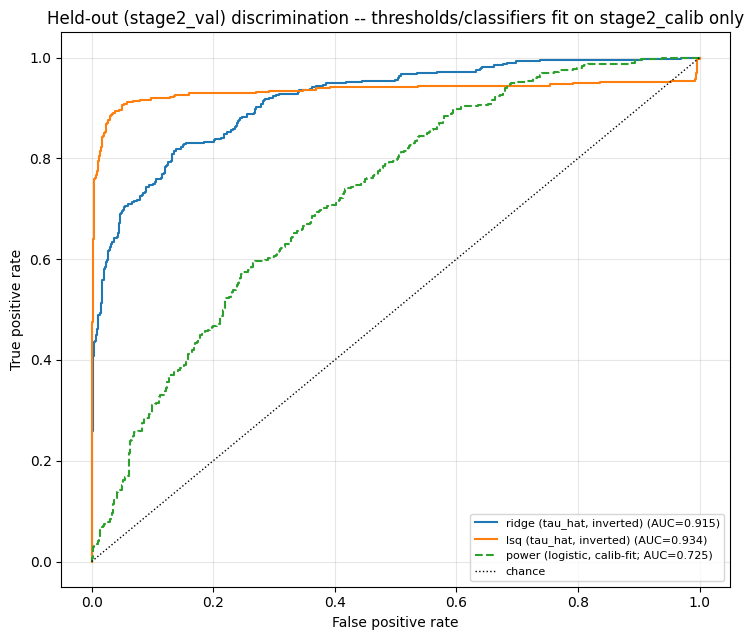


Saved -> /content/drive/MyDrive/gw_postmerger/nb4_5_artifacts/power_baseline_diagnostic.json


In [7]:
# ---------------------------------------------------------------------------
# 6. Held-out AUC + enhanced power diagnostic
# ---------------------------------------------------------------------------
val_passing = [r for r in val_records if r['stage1_pass']]

fig, ax = plt.subplots(figsize=(7.5, 6.5))
auc_results = {}
for name, score_key, higher_is_anomalous in [
        ('ridge (tau_hat, inverted)', 'tau_hat_ridge', False),
        ('lsq (tau_hat, inverted)', 'tau_hat_lsq', False)]:
    subset = [r for r in val_passing if r.get(score_key) is not None]
    y_true = np.array([r['is_anomalous'] for r in subset]).astype(int)
    scores = np.array([r[score_key] for r in subset])
    if not higher_is_anomalous:
        scores = -scores
    if len(np.unique(y_true)) < 2:
        print(f"{name}: skipped (one class only in this subset)")
        continue
    auc = roc_auc_score(y_true, scores)
    auc_results[name] = auc
    fpr_c, tpr_c, _ = roc_curve(y_true, scores)
    ax.plot(fpr_c, tpr_c, label=f'{name} (AUC={auc:.3f})')
    print(f"{name:28s}: held-out AUC={auc:.3f}  (n={len(subset)})")

# -- enhanced power diagnostic --
power_subset = [r for r in val_passing if r.get('total_power_raw') is not None]
y_true_power = np.array([r['is_anomalous'] for r in power_subset]).astype(int)
power_vals = np.array([r['total_power_raw'] for r in power_subset])

auc_power_pos = roc_auc_score(y_true_power, power_vals)
auc_power_neg = roc_auc_score(y_true_power, -power_vals)
best_power_auc = max(auc_power_pos, auc_power_neg)
power_probs = power_clf.predict_proba(power_vals.reshape(-1, 1))[:, 1]  # fit on stage2_calib only
auc_power_logistic = roc_auc_score(y_true_power, power_probs)

print(f"\n--- Power baseline, held-out, enhanced diagnostic ---")
print(f"AUC(power)              = {auc_power_pos:.3f}")
print(f"AUC(-power)             = {auc_power_neg:.3f}")
print(f"best_power_auc          = {best_power_auc:.3f}")
print(f"AUC(logistic, calib-fit)= {auc_power_logistic:.3f}")
if best_power_auc < 0.65:
    verdict = ("weak in EITHER direction -- power carries little tau-discriminating information here")
elif abs(auc_power_pos - 0.5) < 0.05:
    verdict = ("the naive higher-power-is-more-anomalous direction is close to chance, but the flipped "
               "direction carries real signal -- power is not uninformative, it is WEAKER and "
               "DIRECTION-SENSITIVE (best_power_auc indicates real but moderate tau-discriminating "
               "information, below ridge/lsq -- see Section 5's power_operating TPR/FPR for the fair "
               "operating-point comparison).")
else:
    verdict = ("directionally unstable -- correct description is weaker and direction-sensitive, "
               "NOT simply uninformative")
print(f"Verdict: {verdict}")

fpr_p, tpr_p, _ = roc_curve(y_true_power, power_probs)
ax.plot(fpr_p, tpr_p, label=f'power (logistic, calib-fit; AUC={auc_power_logistic:.3f})', ls='--')
ax.plot([0, 1], [0, 1], 'k:', lw=1, label='chance')
ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
ax.set_title('Held-out (stage2_val) discrimination -- thresholds/classifiers fit on stage2_calib only')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'plot_heldout_roc.pdf'))
plt.show()

with open(os.path.join(OUT_DIR, 'power_baseline_diagnostic.json'), 'w') as f:
    json.dump({'auc_power_pos': float(auc_power_pos), 'auc_power_neg': float(auc_power_neg),
               'best_power_auc': float(best_power_auc), 'auc_power_logistic': float(auc_power_logistic),
               **{k: float(v) for k, v in auc_results.items()}}, f, indent=1)
print(f"\nSaved -> {OUT_DIR}/power_baseline_diagnostic.json")

## 7. Summary — corrected interpretation

**On generalization (point 1):** the held-out numbers are **stable under held-out validation within the
`train_block` split** -- not "perfect generalization." This notebook demonstrates the design doesn't
collapse when evaluated on unseen `train_block` noise; it does not demonstrate generalization to
`test_block`, a different detector-noise segment, or any other data the design hasn't been checked
against.

**On ridge vs. lsq (point 2):** do not say they "match." **Ridge gives strong ranking-level separation;
LSQ gives the strongest low-FPR operating-point recall.** Report AUC and operating-point TPR/FPR
together, always -- AUC alone hides the recall gap at the threshold actually used.

**On the power baseline (point 4):** total power is **not uninformative -- it is weaker and
direction-sensitive.** `AUC(-power)=0.725` (held-out) indicates real but moderate tau-discriminating
information, below both ridge and LSQ. Section 5's `power_operating` row (fair, threshold-calibrated for
~1% FPR, comparable in spirit to the ridge/lsq thresholds) is the number to cite -- not `power_default`
(arbitrary 0.5 boundary) and not the naive `AUC(power)` (wrong direction).

**On tuning (point 5):** the ridge estimator's `patience`/threshold parameters are **not tuned** based on
these validation results, and will not be, to avoid overfitting the validation split itself. Ridge
remains configured exactly as it was in Notebook 4 -- a secondary, interpretable, model-light Stage-2
method, not a competitor being optimized against LSQ.

**On scope (point 6):** no CNN, no AST/Mahalanobis, in this notebook or planned for the next one. Both
remain explicitly out of scope -- reintroducing either now would be scope creep requiring a separate fair
protocol neither has been given.


## 8. Band-leakage diagnostic (optional, explanatory only — does not affect any threshold)

Tests the candidate explanation for Section 6's power-baseline finding: does the narrow `[1500,4000]Hz`
CQT-band power become an increasingly incomplete measure of a signal's total energy as tau shortens (and
bandwidth widens), at **fixed matched-filter SNR**? Compares narrow-band power (`total_power_raw`) against
full-passband whitened power (time-domain sum-of-squares over the whole `[F_LOW,F_HIGH]` whitening
passband) across the tau grid. **This section does not feed back into any Stage-1 or Stage-2 threshold**
-- it's purely explanatory, run on `stage2_calib` (chosen arbitrarily between the two pools since nothing
here is fit or evaluated as a result).


tau=  1ms: ratio(narrow-band / full-passband power) = 0.0312 +/- 0.0010
tau=  3ms: ratio(narrow-band / full-passband power) = 0.0320 +/- 0.0009
tau=  5ms: ratio(narrow-band / full-passband power) = 0.0319 +/- 0.0011
tau= 10ms: ratio(narrow-band / full-passband power) = 0.0324 +/- 0.0010
tau= 20ms: ratio(narrow-band / full-passband power) = 0.0328 +/- 0.0014
tau= 40ms: ratio(narrow-band / full-passband power) = 0.0336 +/- 0.0014


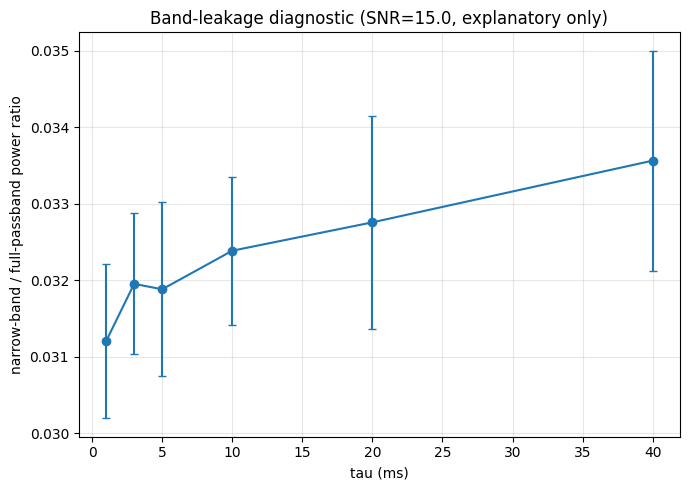


Ratio increases monotonically with tau: False
NOT cleanly monotonic -- band leakage may be a partial explanation at most; the power-baseline finding from Section 6 stands regardless (it doesn't depend on this mechanism being fully confirmed), but the mechanism itself would need more investigation before citing it as settled.

Saved -> /content/drive/MyDrive/gw_postmerger/nb4_5_artifacts/bandleak_diagnostic.json


In [8]:
# ---------------------------------------------------------------------------
# 8. Band-leakage diagnostic (explanatory only)
# ---------------------------------------------------------------------------
def whitened_full_passband_power(window):
    """Time-domain sum-of-squares of the whitened window -- energy across the FULL [F_LOW, F_HIGH]
    whitening passband, unlike total_power_raw which only sees the narrow [1500,4000]Hz CQT band mask.
    Explanatory only (Section 8) -- never used as a Stage-1/Stage-2 feature or threshold input."""
    return float(np.sum(window**2))

N_BANDLEAK_PER_TAU = 40
BANDLEAK_SNR = 15.0
bandleak_results = {}
for tau_ms in TAU_GRID_MS:
    narrow_powers, full_powers = [], []
    for _ in range(N_BANDLEAK_PER_TAU):
        f_peak = rng.uniform(1500.0, 4000.0)
        w, _, _ = inject_and_whiten('stage2_calib', f_peak=f_peak, tau=tau_ms / 1000.0,
                                     target_snr=BANDLEAK_SNR)
        narrow_powers.append(total_power_raw(w))
        full_powers.append(whitened_full_passband_power(w))
    narrow_powers = np.array(narrow_powers)
    full_powers = np.array(full_powers)
    ratio = narrow_powers / full_powers
    bandleak_results[tau_ms] = {'narrow_mean': float(narrow_powers.mean()),
                                 'full_mean': float(full_powers.mean()),
                                 'ratio_mean': float(ratio.mean()), 'ratio_std': float(ratio.std())}
    print(f"tau={tau_ms:3d}ms: ratio(narrow-band / full-passband power) = "
          f"{ratio.mean():.4f} +/- {ratio.std():.4f}")

ratios = [bandleak_results[t]['ratio_mean'] for t in TAU_GRID_MS]
fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(TAU_GRID_MS, ratios, yerr=[bandleak_results[t]['ratio_std'] for t in TAU_GRID_MS],
            marker='o', capsize=3)
ax.set_xlabel('tau (ms)'); ax.set_ylabel('narrow-band / full-passband power ratio')
ax.set_title(f'Band-leakage diagnostic (SNR={BANDLEAK_SNR}, explanatory only)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'plot_bandleak_diagnostic.pdf'))
plt.show()

is_monotonic_increasing = all(ratios[i] <= ratios[i + 1] + 1e-6 for i in range(len(ratios) - 1))
print(f"\nRatio increases monotonically with tau: {is_monotonic_increasing}")
if is_monotonic_increasing:
    print("Consistent with the band-leakage hypothesis: shorter tau -> proportionally less energy "
          "captured within the narrow [1500,4000]Hz band mask at fixed total (wideband) SNR.")
else:
    print("NOT cleanly monotonic -- band leakage may be a partial explanation at most; the power-baseline "
          "finding from Section 6 stands regardless (it doesn't depend on this mechanism being fully "
          "confirmed), but the mechanism itself would need more investigation before citing it as settled.")

with open(os.path.join(OUT_DIR, 'bandleak_diagnostic.json'), 'w') as f:
    json.dump(bandleak_results, f, indent=1)
print(f"\nSaved -> {OUT_DIR}/bandleak_diagnostic.json")

## 9. FROZEN DESIGN SPECIFICATION

**Status: pending explicit confirmation after this notebook (including Section 8) is run and reviewed —
not automatically in effect just because the notebook executes without error.**

If confirmed, the frozen Stage-1 + Stage-2 design is:

- **Stage 1:** `norm_lambda1` (the empirically-null-normalized graph-spectral statistic), threshold
  calibrated at `alpha=0.01` on `calib_block`.
- **Stage 2, primary:** LSQ `tau_hat`, threshold fitted on `stage2_calib` (1st percentile of the
  standard-tau distribution).
- **Stage 2, secondary:** ridge/energy-decay `tau_hat`, threshold fitted on `stage2_calib` (same
  protocol) -- reported alongside LSQ, not as a replacement for it, per Section 7's point 2 correction.
- **Baselines:** total power (`power_default`, shown for contrast only), inverted power (`AUC(-power)`),
  and calibrated logistic power (`power_operating`, the fair operating-point comparison).
- **Explicitly excluded from v1:** CNN, AST/Mahalanobis.

**Only after this freeze is explicitly confirmed should the one-time, final `test_block` evaluation be
built and run.** This notebook does not perform that evaluation and does not load `test_block`.

```
nb4_5_artifacts/
  calib_records.json, val_records.json                  # full per-sample sweep results, both pools
  heldout_conditional_vs_endtoend.json                   # Section 5 -- ridge/lsq/power_operating numbers
  plot_heldout_roc.pdf, power_baseline_diagnostic.json   # Section 6
  plot_bandleak_diagnostic.pdf, bandleak_diagnostic.json # Section 8 -- explanatory only
```

**`test_block` remains unloaded and untouched throughout this notebook.**
